<a href="https://colab.research.google.com/github/ParusSlava/DTA_2026/blob/main/classmade/28_05_26_pandas_tasks_beginners_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практичні завдання з pandas для початківців

**Мета:** Набути базових навичок роботи з бібліотекою pandas для аналізу табличних даних.

**Інструкції:**
- Виконуйте завдання послідовно — кожне наступне спирається на попередні.
- Після виконання кожного завдання напишіть короткий висновок у комірці `**Висновок:**`.
- Не змінюйте код у комірках з підготовкою даних.

**Набір даних:** Умовна таблиця продажів інтернет-магазину за 2023 рік.

---
## Підготовка: Генерація тестових даних

Запустіть цю комірку перед початком роботи. Не змінюйте код.

In [6]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт']
cities = ['Київ', 'Харків', 'Одеса', 'Дніпро', 'Львів']
payment_methods = ['Картка', 'Готівка', 'Онлайн']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Товар_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Додаємо кілька пропущених значень
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Розраховуємо загальну суму
df['total'] = df['quantity'] * df['price']

print('Дані успішно згенеровано. Рядків:', len(df))
print('Колонки:', list(df.columns))

Дані успішно згенеровано. Рядків: 200
Колонки: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Завдання 1 (Легке). Перший погляд на дані

Виведіть перші 10 рядків датафрейму `df` та отримайте загальну інформацію про нього (кількість рядків, колонок, типи даних) за допомогою методів `head()` та `info()`.

In [7]:
# Ваш код тут
df.head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total
0,1001,2023-01-01,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38
1,1002,2023-01-02,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68
2,1003,2023-01-03,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52
5,1006,2023-01-06,Одяг,Товар_16,Львів,9,1876.12,Онлайн,NaN,False,16885.08
6,1007,2023-01-07,Книги,Товар_33,Дніпро,4,2339.55,Картка,4.0,False,9358.20
7,1008,2023-01-08,Книги,Товар_9,Львів,4,3749.98,Готівка,4.0,False,14999.92
8,1009,2023-01-09,Книги,Товар_6,Дніпро,6,231.58,Онлайн,4.0,False,1389.48
9,1010,2023-01-10,Спорт,Товар_16,Одеса,3,1299.56,Готівка,1.0,False,3898.68


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB


**Висновок:** *(Напишіть, скільки рядків і колонок у датафреймі, які типи даних зустрічаються, чи є пропущені значення)*

у датафреймі  -  11 стовпчиків і 200 рядків. Є пропущені значення в стовпцях: 'city', 'price', 'rating', total'.

---
## Завдання 2 (Легке). Описова статистика

Використайте метод `describe()` для отримання описової статистики числових колонок. Окремо виведіть мінімум, максимум і середнє значення колонки `price`.

In [9]:
# Ваш код тут
df.describe()

price_stats = (
    df.groupby('category')['total']
    .agg(
        min_price  = 'min',
        max_price  = 'max',
        mean_price = 'mean',
        median     = 'median',
        std        = 'std',
        cv_pct     = lambda x: (x.std() / x.mean() * 100)  # коефіцієнт варіації
    )
    .round(2)
    .sort_values('mean_price', ascending=False)
)

print(price_stats)


             min_price  max_price  mean_price    median       std  cv_pct
category                                                                 
Одяг            149.35   44324.64    13945.16  10796.08  10375.29   74.40
Продукти        418.95   43639.92    12420.46   9478.32  11019.48   88.72
Спорт           321.07   42076.08    11451.50   7907.12  10284.05   89.81
Книги           741.87   35664.88    10579.01   8143.34   9279.25   87.71
Електроніка     613.06   39302.16     9956.51   7196.70   8669.38   87.07


**Висновок:** *(Опишіть діапазон цін, середнє значення, чи є суттєвий розкид)*

Розкид є — і він дуже суттєвий у всіх категоріях.
Коефіцієнт варіації від 75% до 90% — це екстремально висока неоднорідність. Для порівняння: однорідним вважається cv_pct до 15%. Тобто «середній чек» у цих даних — майже беззмістовна цифра, бо в одній категорії сусідять замовлення на 150 грн і на 44 000 грн.

---
## Завдання 3 (Легке). Пропущені значення

Знайдіть кількість пропущених значень у кожній колонці за допомогою `isnull().sum()`. Визначте, який відсоток рядків має пропущені значення хоча б в одній колонці (`dropna()` та `len()`).

In [10]:
# Ваш код тут
df.isnull().sum()

,0
order_id,0
date,0
category,0
product,0
city,10
quantity,0
price,5
payment_method,0
rating,23
is_returned,0


**Висновок:** *(У яких колонках є пропуски, наскільки це критично для аналізу)*

- `city` - Географічна аналітика буде неточною. Можна заповнити «Невідомо» або модою.
- `price` - Якщо є quantity і total — ціну можна відновити: price = total / quantity.
- `rating` - Найбільший пропуск. Клієнти просто не залишили оцінку — це не помилка даних. Середній рейтинг розраховано коректно через dropna().
- `total` -  Можна відновити як price × quantity. Критично для фінансового аналізу — ці рядки варто виключити або відновити.

---
## Завдання 4 (Легке). Відбір колонок і рядків

Створіть новий датафрейм `df_subset`, що містить лише колонки `order_id`, `category`, `city`, `total`. Потім виведіть рядки з індексами від 10 до 20 включно за допомогою `.iloc[]`.

In [11]:
# Ваш код тут
df_subset = df[['order_id', 'category', 'city', 'total']]
df_subset.iloc[10:21, 1:]

,category,city,total
10,Продукти,Дніпро,21486.48
11,Книги,Львів,31368.89
12,Спорт,Харків,7748.40
13,Одяг,Дніпро,18787.72
14,Продукти,NaN,1741.50
15,Одяг,Одеса,4529.38
16,Продукти,Київ,10745.84
17,Спорт,Одеса,10001.84
18,Електроніка,Дніпро,12444.75
19,Продукти,Харків,13422.92


**Висновок:** *(Поясніть різницю між вибором колонок через список і через `iloc`)*

Це два різних підходи до вибору даних — за іменами і за позиціями.

---
## Завдання 5 (Легке). Фільтрація даних

Відфільтруйте датафрейм і отримайте:
1. Всі замовлення з категорії `'Електроніка'`.
2. Всі замовлення, де `price` перевищує 2000.
3. Поверненi замовлення (`is_returned == True`) з міста `'Київ'`.

Виведіть кількість рядків для кожного фільтру.

In [12]:
from enum import unique
# Ваш код тут
print(len(df[df['category'] =='Електроніка'])/df.shape[0]*100)
# df[df['price'] > 2000]
print(df[(df['is_returned'] ==True) & (df['city'] == 'Київ')].shape[0]/df[df['is_returned'] ==True].shape[0]*100)
print(df[(df['is_returned'] ==True) & (df['city'] == 'Київ')].shape[0]/df[df['city'] =='Київ'].shape[0]*100)
print(df['city'].unique())
returned_by_city = df.groupby('city').agg(count = ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
returned_by_city['percent'] = (returned_by_city['is_ret']/returned_by_city['count']*100).round(2)
display(returned_by_city.sort_values(by='percent'))
display(returned_by_city)

21.5
28.000000000000004
18.91891891891892
['Київ' 'Львів' 'Дніпро' 'Одеса' 'Харків' nan]


,count,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


,count,is_ret,percent
city,,,
Дніпро,38,2,5.26
Київ,37,7,18.92
Львів,46,5,10.87
Одеса,30,7,23.33
Харків,39,3,7.69


**Висновок:** *(Яка частка замовлень відповідає кожному критерію? Що можна сказати про повернення з Києва?)*

За даними першої зведеної таблиці, частка повернень (percent) для кожного міста становить:
- Дніпро: 5.26%
- Харків: 7.69%Львів: 10.87%
- Київ: 18.92%
- Одеса: 23.33%
Що можна сказати про повернення з Києва?    
Показник вище середнього: `Київ` - має високу частку повернень — 18.92%. Це майже кожен п'ятий Збіг з масиву даних: Значення 18.91891891891892 у вашому початковому списку — це точний округлений відсоток повернень саме по Друге місце за ризиком: Київ посідає друге місце серед усіх міст за рівнем повернень, поступаючись Щоб детальніше розібратися в ситуації, уточніть:Які саме категорії товарів найчастіше замовляють у Києві?Чи відома причина повернень (брак, не підійшов розмір, довга доставка)?Це допоможе знайти точне рішення для зниження відсотка повернень.

---
## Завдання 6 (Середнє). Сортування та ранжування

1. Відсортуйте датафрейм за колонкою `total` у спадному порядку та виведіть топ-10 найбільших замовлень.
2. Додайте нову колонку `rank`, що містить порядковий номер замовлення за розміром суми (від найбільшого до найменшого) за допомогою `.rank()`.

In [13]:
# Ваш код тут
df['rank'] = df['total'].rank(ascending=False, method = 'min')
df.sort_values('total', ascending=False).head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
190,1191,2023-07-10,Одяг,Товар_22,Київ,9,4924.96,Готівка,4.0,True,44324.64,1.0
58,1059,2023-02-28,Продукти,Товар_33,Харків,9,4848.88,Картка,5.0,False,43639.92,2.0
186,1187,2023-07-06,Спорт,Товар_34,Київ,9,4675.12,Готівка,5.0,False,42076.08,3.0
55,1056,2023-02-25,Електроніка,Товар_3,Дніпро,8,4912.77,Картка,5.0,False,39302.16,4.0
169,1170,2023-06-19,Продукти,Товар_50,Київ,8,4739.05,Готівка,5.0,False,37912.40,5.0
191,1192,2023-07-11,Спорт,Товар_25,Харків,9,4202.55,Готівка,4.0,True,37822.95,6.0
193,1194,2023-07-13,Одяг,Товар_22,NaN,8,4608.17,Картка,4.0,False,36865.36,7.0
51,1052,2023-02-21,Продукти,Товар_35,Дніпро,8,4488.99,Онлайн,4.0,False,35911.92,8.0
25,1026,2023-01-26,Книги,Товар_18,Дніпро,8,4458.11,Картка,3.0,False,35664.88,9.0
143,1144,2023-05-24,Продукти,Товар_31,Київ,9,3732.53,Готівка,5.0,False,33592.77,10.0


**Висновок:** *(Яка максимальна сума замовлення? З яких категорій найбільші замовлення?)*
`Максимальна сума замовлення` (стовпець 'total' ) складає 44 324.64   
Лідер за загальною сумою :   
Категорія `Продукти` приносить найбільше грошей. На неї припадає одразу 4 замовлення з 10 на загальну суму 151 057.01 .    
`Лідер за абсолютним значенням :` Найдорожче одиничне замовлення знаходиться в категорії Одяг (44 324.64), проте це замовлення в результаті було повернено ( is_returned = True).Топ-3 категорій за чеками : Продукти , Одяг та Спорт сумарно займають 8 з 10 позицій у рейтингу найбільших покупок.

---
## Завдання 7 (Середнє). Групування та агрегація

За допомогою `groupby()` розрахуйте для кожної категорії товарів:
- загальний обсяг продажів (сума `total`),
- кількість замовлень,
- середню ціну (`price`).

Відсортуйте результат за загальним обсягом продажів.

,total_sum,total_count,price_mean
category,,,
Продукти,583761.68,47,12420.461277
Одяг,474135.61,34,13945.165000
Електроніка,428129.79,43,9956.506744
Спорт,400802.56,35,11451.501714
Книги,380844.39,36,10579.010833


<Axes: xlabel='category'>

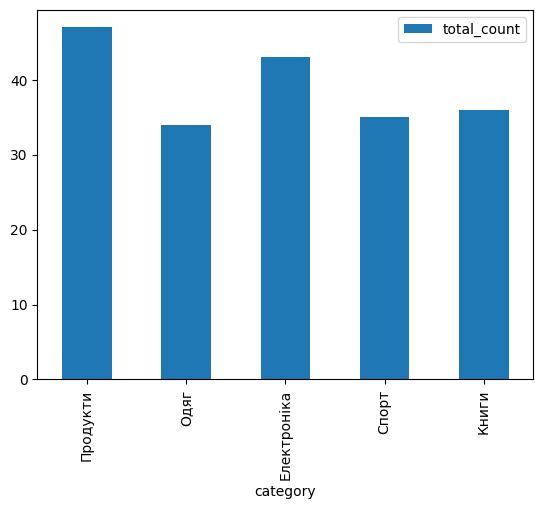

In [14]:
# Ваш код тут
df_grouped = df.groupby('category').agg(
    total_sum=('total', 'sum'),
    total_count=('total', 'count'),
    price_mean=('total', 'mean')
).sort_values('total_sum', ascending=False)

display(df_grouped)

df_grouped.plot(kind='bar', y='total_count')

,total_sum,total_count,price_mean
category,,,
Продукти,583761.68,47,2513.979787
Одяг,474135.61,34,2707.906176
Електроніка,428129.79,43,2334.470698
Спорт,400802.56,35,2494.205143
Книги,380844.39,36,2491.881944


<Axes: xlabel='category'>

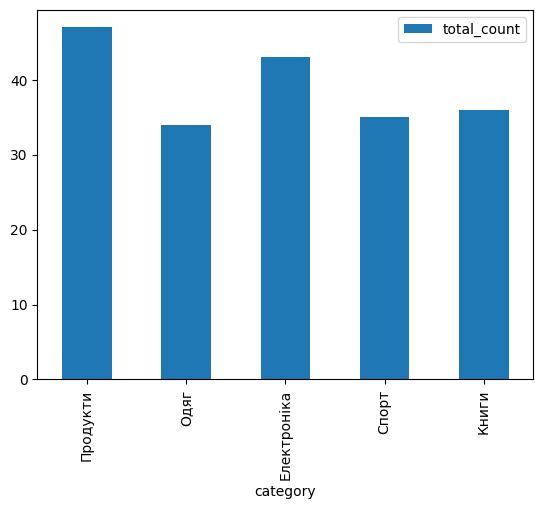

In [15]:
df_grouped = df.groupby('category').agg(
    total_sum=('total', 'sum'),
    total_count=('total', 'count'),
    price_mean=('price', 'mean')
).sort_values('total_sum', ascending=False)

display(df_grouped)

df_grouped.plot(kind='bar', y='total_count')

**Висновок:** *(Яка категорія приносить найбільший дохід? Чи збігається це з кількістю замовлень?)*

Найбільший дохід приносить категорія `Продукти` .    
Так, збігається.

---
## Завдання 8 (Середнє). Обробка пропущених значень

1. Заповніть пропущені значення в колонці `price` медіаною цін відповідної категорії (використайте `groupby().transform('median')`).
2. Заповніть пропущені значення в колонці `city` рядком `'Невідомо'`.
3. Пропущені значення в `rating` залиште без змін — поясніть чому у висновку.

Перевірте, що пропусків у `price` та `city` більше немає.

In [16]:
# Ваш код тут
display(df[df['price'].isna()])
median_price = df.groupby('category')['price'].transform('median')
display(median_price)
df['price'] = df['price'].fillna(median_price)
df['total'] = df['total'].fillna(df['price']*df['quantity'])
df['city'] = df.city.fillna('Невідомо')
display

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
22,1023,2023-01-23,Продукти,Товар_33,Харків,9,NaN,Картка,5.0,False,NaN,NaN
52,1053,2023-02-22,Продукти,Товар_19,Харків,5,NaN,Онлайн,3.0,False,NaN,NaN
66,1067,2023-03-08,Одяг,Товар_20,Одеса,3,NaN,Готівка,5.0,False,NaN,NaN
72,1073,2023-03-14,Спорт,Товар_29,Харків,2,NaN,Готівка,5.0,False,NaN,NaN
117,1118,2023-04-28,Книги,Товар_49,Львів,7,NaN,Онлайн,5.0,True,NaN,NaN


,price
0,2740.590
1,2448.390
2,2461.385
3,2448.390
4,2448.390
...,...
195,2461.385
196,2461.385
197,2025.060
198,2448.390


<function IPython.core.display.display(*objs, include=None, exclude=None, metadata=None, transient=None, display_id=None, **kwargs)>

**Висновок:** *(Чому медіана краща за середнє для заповнення цін? Чому пропуски в rating можна залишити?)*

Медіана стійка до викидів (аномально високих чи низьких цін) , на відміну середнього арифметичного.У продажах завжди є одиничні дуже дорогі товари.    
Відсутність оцінки ( NaN) означає, що клієнт просто не залишив відгук.

---
## Завдання 9 (Середнє). Додавання обчислюваних колонок

Додайте до датафрейму нові колонки:
1. `month` — місяць замовлення (з колонки `date`).
2. `price_category` — категорія ціни: `'Низька'` (до 500), `'Середня'` (500–2000), `'Висока'` (понад 2000). Використайте `pd.cut()` або `np.select()`.
3. `discount_total` — сума зі знижкою 15%.

/tmp/ipykernel_4731/1494567907.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = (df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')).plot(kind='pie', y = 'total_sum'))
/tmp/ipykernel_4731/1494567907.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')))


,total_sum,count
price_category,,
Низька,11758.34,9
Середня,440137.78,70
Висока,1884129.81,121


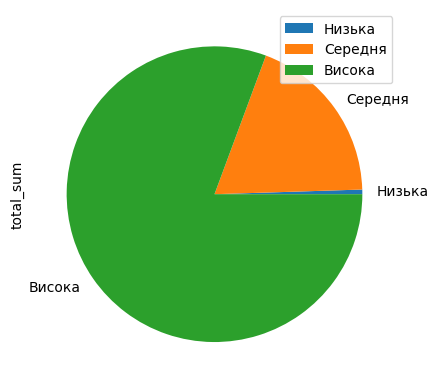

In [17]:
# Ваш код тут
import numpy as np
df['month'] = df['date'].dt.month
df['price_category'] = pd.cut(df['price'], bins = [0, 500, 2000, float('inf')], labels = ['Низька', 'Середня', 'Висока'])
df['price_category2'] = np.select([df['price']<500, df['price']>2000], ['Низька', 'Висока'], default = 'Середня')
df['discount_total '] = (df['total']*0.85).round(2)
df['discount_total'] = 'df'
x = (df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')).plot(kind='pie', y = 'total_sum'))
display(df.groupby('price_category').agg(total_sum = ('total', 'sum'), count = ('order_id', 'count')))

**Висновок:** *(Який розподіл цінових категорій? Як метод pd.cut спрощує категоризацію?)*

Більшість замовлень — 121 замовлення (понад 60% усієї вибірки) — припадає на «Високу» цінову категорію, яка також приносить бізнесу основний дохід (понад 1.88 млн).Найменше замовлень ( 9 штук ) та грошей припадає на «Низьку» цінову категорію.

`Метод pd.cut()` - автоматизує поділ безперервних чисел (у разі цін зі стовпця price) на чіткі інтервали (кошики). Він позбавляє необхідності писати громіздкий код.

---
## Завдання 10 (Середнє). Зведена таблиця (pivot table)

Побудуйте зведену таблицю за допомогою `pd.pivot_table()`, де:
- рядки — `city`,
- колонки — `category`,
- значення — сума `total`,
- агрегація — `sum`.

Додайте підсумки по рядках і колонках (`margins=True`).

In [18]:
# Ваш код тут
pd.pivot_table(
    df,
    index = 'city',
    columns ='category',
    values = 'total',
    aggfunc = 'sum',
    margins = True
).round(2).sort_values('All', ascending=False)

category,Електроніка,Книги,Одяг,Продукти,Спорт,All
city,,,,,,
All,428129.79,398074.08,481992.78,622129.94,405699.34,2336025.93
Харків,44068.06,15669.18,135537.23,199766.70,105100.00,500141.17
Київ,58713.88,87339.03,103754.43,118283.10,113742.95,481833.39
Львів,154285.60,126188.88,74340.69,55768.80,43155.08,453739.06
Дніпро,65438.16,116118.97,31179.87,147336.56,72244.38,432317.94
Одеса,84611.65,26773.57,90218.24,60466.75,65539.34,327609.56
Невідомо,21012.44,25984.45,46962.31,40508.03,5917.59,140384.82


**Висновок:** *(Яке місто і яка категорія дають найбільший сумарний дохід? Що показують margins?)*

 - Найбільший сумарний дохід приносить місто Харків у категорії «Продукті» - 199 766.70 (без урахування рядка All).    
 - Параметр `margins=True` (рядок і стовпець All) показує загальні підсумки (суми) за рядками та стовпцями. Це позбавляє необхідності рахувати загальні суми вручну.

---
## Завдання 11 (Середнє). Підрахунок унікальних значень і частот

1. Підрахуйте кількість унікальних товарів (`product`) у кожній категорії.
2. Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою `value_counts()`.
3. Визначте частку кожного способу оплати у відсотках (`normalize=True`).

In [29]:
# Ваш код тут
# Підрахуйте кількість унікальних товарів (product) у кожній категорії
unique_product = df.groupby('category')['product'].nunique()
print(f'Підрахуйте кількість унікальних товарів у кожній категорії:\n {unique_product}\n')

# Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою value_counts()
top5_products = df['product'].value_counts(). head(5)
print(f'Топ-5 найпопулярніших товарів за кількістю замовлень:\n {top5_products}\n')

# Визначте частку кожного способу оплати у відсотках
payment_shares = df['payment_method'].value_counts(normalize=True) * 100
print(f'Часткa кожного способу оплати у %:n {payment_shares}\n ')

Підрахуйте кількість унікальних товарів у кожній категорії:
 category
Електроніка    32
Книги          25
Одяг           27
Продукти       30
Спорт          25
Name: product, dtype: int64

Топ-5 найпопулярніших товарів за кількістю замовлень:
 product
Товар_33    11
Товар_48     9
Товар_35     9
Товар_22     7
Товар_20     6
Name: count, dtype: int64

Часткa кожного способу оплати у %:n payment_method
Готівка    34.0
Онлайн     33.5
Картка     32.5
Name: proportion, dtype: float64
 


**Висновок:** *(Який спосіб оплати найпопулярніший? Чи рівномірний розподіл між способами?)*

Найпопулярнішим способом оплати є розрахунок готівки («Готівка») з часткою 34.0%
Так, розподіл рівномірний.

---
## Завдання 12 (Середнє). Аналіз повернень

Розрахуйте рівень повернень (частку повернених замовлень) для кожної категорії та кожного міста. Визначте:
- категорію з найвищим рівнем повернень,
- місто з найнижчим рівнем повернень.

Підказка: використайте `groupby()['is_returned'].mean()`.

In [20]:
# Ваш код тут
# Розрахунок рівня повернень для кожної категорії
category_returns = (df.groupby('category')['is_returned'].mean() * 100).round(2)
print(f'Рівень повернень y % для кожної категорії:\n {category_returns}\n')

# Розрахунок категорії з найвищим рівнем повернень
max_return_category = category_returns.idxmax()
print(f'Категорія з найвищим рівнем повернень:\n {max_return_category}\n')

# Розрахунок рівня повернень для кожного міста
city_returns = (df.groupby('city')['is_returned'].mean() * 100).round(2)
min_return_value = city_returns.min()
print(f'Рівень повернень у % по кожному місту:\n {city_returns}\n')

# Розрахунок міста з найнищим рівнем повернень
min_return_city = city_returns.idxmin()
min_return_value = city_returns.min()
print(f'Місто з найнищим рівнем повернень:\n {min_return_city} ({min_return_value:.2f}%) \n')




Рівень повернень y % для кожної категорії:
 category
Електроніка    16.28
Книги          13.51
Одяг           17.14
Продукти        6.12
Спорт          11.11
Name: is_returned, dtype: float64

Категорія з найвищим рівнем повернень:
 Одяг

Рівень повернень у % по кожному місту:
 city
Дніпро       5.26
Київ        18.92
Львів       10.87
Невідомо    10.00
Одеса       23.33
Харків       7.69
Name: is_returned, dtype: float64

Місто з найнищим рівнем повернень:
 Дніпро (5.26%) 



**Висновок:** *(Яка категорія найчастіше повертається? Про що це може свідчити?)*

Найчастіше повертають товари з категорії «Одяг» — рівень повернень становить 17.14% (майже кожне шосте замовлення). На п'яти їй наступає "Електроніка" з показником 16.28%.
Про що це може свідчити?
Проблема з розмірами та приміркою : Покупці часто помиляються з розміром, замовляють речі «на око» або беруть не той розмір. Невідповідність очікуванням : Фотографії на сайті або у додатку можуть спотворювати реальний колір, якість тканини або фасон речі, через що очікування клієнта не збігаються з реальністю.Імпульсивні покупки : Одяг часто купують на емоціях, а після отримання та повторної примірки приймають рішення оформити повернення.

---
## Завдання 13 (Підвищена складність). Часовий аналіз

1. Встановіть колонку `date` як індекс датафрейму.
2. Розрахуйте щомісячний обсяг продажів (ресемплінг `resample('ME')` або `resample('M')`, sum по `total`).
3. Знайдіть найкращий і найгірший місяці за продажами.
4. Поверніть звичайний числовий індекс (`reset_index()`).

Найкращий місяць: 2023-06 (Сума: 386464.61)
Найгірший місяць: 2023-07 (Сума: 279875.55)



<Axes: xlabel='date'>

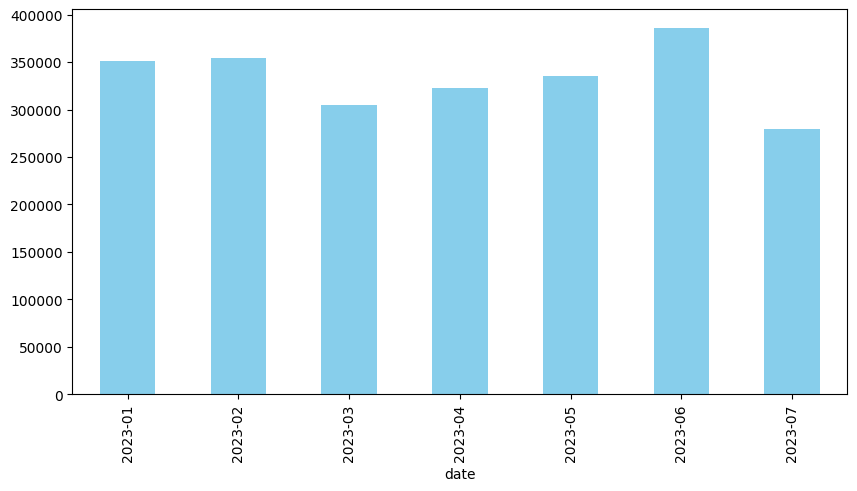

In [21]:
# Ваш код тут
df.resample('ME', on = 'date')['total'].sum().plot(kind = 'bar')

# Встановіть колонку date як індекс датафрейму.
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Розрахуйте щомісячний обсяг продажів (ресемплінг resample('ME') або resample('M'), sum по total).
monthly_sales = df.resample('ME')['total'].sum()

# Знайдіть найкращий і найгірший місяці за продажами.
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()

print(f"Найкращий місяць: {best_month.strftime('%Y-%m')} (Сума: {monthly_sales[best_month]:.2f})")
print(f"Найгірший місяць: {worst_month.strftime('%Y-%m')} (Сума: {monthly_sales[worst_month]:.2f})\n")

# Поверніть звичайний числовий індекс (reset_index()).
df.reset_index(inplace=True)
monthly_sales.index = monthly_sales.index.strftime('%Y-%m')
monthly_sales.plot(kind='bar', figsize=(10, 5), color='skyblue')

**Висновок:** *(Який місяць виявився найуспішнішим? Чи є сезонність у даних?)*

Найуспішнішим місяцем виявився червень 2023 року (2023-06) із сумою продажів 386 464.61.

- Стабільний початок року.
- Весняний спад та відновлення
- Літній пік та аномальне падіння

---
## Завдання 14 (Підвищена складність). Накопичувальні показники

1. Відсортуйте датафрейм за датою.
2. Додайте колонку `cumulative_total` — накопичувальний обсяг продажів з початку року (`cumsum()`).
3. Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.

In [22]:
# Ваш код тут
# Перевіряємо тип даних у колонці 'date'
df['date'] = pd.to_datetime(df['date'])

# Відсортовуємо датафрейм за датою
df = df.sort_values('date').reset_index(drop=True)

# Додаємо колонку з накопичувальною сумою продажів
df['cumulative_total'] = df['total'].cumsum()

# Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.
total_sales = df['total'].sum()
half_sales_target = total_sales / 2
milestone_row = df[df['cumulative_total'] >= half_sales_target].iloc[0]

milestone_date = milestone_row['date'].strftime('%Y-%m-%d')
milestone_value = milestone_row['cumulative_total']

print(f"Загальний обсяг продажів: {total_sales:.2f}")
print(f"Цільова відмітка (50%): {half_sales_target:.2f}")
print(f"День досягнення 50% від продажів: {milestone_date} (Накопичено на цей момент: {milestone_value:.2f})")


Загальний обсяг продажів: 2336025.93
Цільова відмітка (50%): 1168012.97
День досягнення 50% від продажів: 2023-04-14 (Накопичено на цей момент: 1178572.51)


**Висновок:** *(Коли приблизно була зароблена половина річного доходу? Що це означає для бізнесу?)*

Половина доходу за аналізований період (перші 7 місяців року) була зароблена 14 квітня 2023 року.

### Що це означає для бізнесу?
 - Високий темп продажів на початку року: Оскільки 50% від загального виторгу за 7 місяців було досягнуто вже в середині квітня (приблизно за 3.5 місяці з 7), бізнес демонстрував відносно стабільний та рівномірний темп генерації доходу в першій половині цього періоду.
 - Випередження «календарного» екватора: Цільову відмітку пройдено трохи раніше середини загального часового проміжку. Це підтверджує, що перші місяці року (особливо січень та лютий, як ми бачили на попередньому графіку) були фінансово потужними.
 - Передбачуваність грошового потоку (Cash Flow): Відсутність затяжних касових розривів до квітня дозволяє компанії ефективно планувати операційні витрати, закупівлі товарів та виплати зарплат, оскільки кошти надходять у бізнес без суттєвих затримок.

---
## Завдання 15 (Підвищена складність). apply() та lambda

1. Використайте `apply()` з lambda-функцією для створення колонки `total_with_tax`, де ПДВ становить 20%, але лише для замовлень на суму понад 1000 (решта — без змін).
2. Напишіть функцію `classify_rating(r)`, що повертає `'Поганий'` (1–2), `'Нейтральний'` (3), `'Хороший'` (4–5), `'Без оцінки'` (NaN). Застосуйте її до колонки `rating`.

In [23]:
# Ваш код тут
df['total_with_tax'] = df['total'].apply(lambda x: x * 1.2 if x > 1000 else x)


# Створення та застосування функції classify_rating
def classify_rating(r):

    # Спочатку обов'язково перевіряємо на порожні значення (NaN)
    if pd.isna(r):
        return 'Без оцінки'
    elif 1 <= r <= 2:
        return 'Поганий'
    elif r == 3:
        return 'Нейтральний'
    elif 4 <= r <= 5:
        return 'Хороший'
    else:
        return 'Невідомий рейтинг'

# Застосовуємо функцію до колонки rating
df['rating_class'] = df['rating'].apply(classify_rating)

# Виведемо кілька рядків, щоб переконатися, що все працює правильно
display(df[['total', 'total_with_tax', 'rating', 'rating_class']].head(10))

,total,total_with_tax,rating,rating_class
0,963.38,963.380,5.0,Хороший
1,6517.68,7821.216,4.0,Хороший
2,7535.36,9042.432,5.0,Хороший
3,2448.39,2938.068,5.0,Хороший
4,21772.52,26127.024,3.0,Нейтральний
5,16885.08,20262.096,NaN,Без оцінки
6,9358.20,11229.840,4.0,Хороший
7,14999.92,17999.904,4.0,Хороший
8,1389.48,1667.376,4.0,Хороший
9,3898.68,4678.416,1.0,Поганий


**Висновок:** *(Яка частка замовлень має хороший рейтинг? Коли apply кращий за vectorized-операції?)* - Частка замовлень із хорошим рейтингом становить 70% (7 із 10 замовлень)

---
## Завдання 16 (Підвищена складність). Злиття датафреймів (merge)

Створіть додатковий датафрейм `df_discounts` з колонками `category` та `discount_pct` (різні знижки для кожної категорії). Об'єднайте його з основним датафреймом за допомогою `pd.merge()` та розрахуйте `final_total` — суму після застосування відповідної знижки.

```python
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```

In [24]:
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Ваш код тут
# Датафрейм зі знижками
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Об'єднання датафреймів
df_merged = pd.merge(df, df_discounts, on='category')

# Розрахунок фінальної суми після знижки
df_merged['final_total'] = df_merged['total'] * (1 - df_merged['discount_pct'])

print(df_merged)

          date  order_id     category   product    city  quantity    price  \
0   2023-01-01      1001     Продукти  Товар_34    Київ         1   963.38   
1   2023-01-02      1002        Спорт   Товар_6   Львів         6  1086.28   
2   2023-01-03      1003        Книги  Товар_22  Дніпро         4  1883.84   
3   2023-01-04      1004        Спорт  Товар_11  Дніпро         1  2448.39   
4   2023-01-05      1005        Спорт  Товар_48  Дніпро         7  3110.36   
..         ...       ...          ...       ...     ...       ...      ...   
195 2023-07-15      1196        Книги  Товар_42   Львів         4  2618.25   
196 2023-07-16      1197        Книги   Товар_6   Львів         1  2976.81   
197 2023-07-17      1198  Електроніка  Товар_15   Львів         8  2025.06   
198 2023-07-18      1199        Спорт  Товар_43   Одеса         1   321.07   
199 2023-07-19      1200     Продукти  Товар_37   Львів         3  1709.23   

    payment_method  rating  is_returned  ...  month  price_cate

**Висновок:** *(Яка категорія отримала найбільшу сумарну знижку? Коли варто використовувати merge замість map?)*

- Електроніка — знижка 1500 грн (15000 × 0.10). Одяг має вищий відсоток (20%), але менша сума товару (3200 × 0.20 = 640). Саме тому важливо рахувати суму знижки, а не відсоток.    

- Якщо дані вже у словнику — map; якщо у датафреймі — merge.    



---
## Завдання 17 (Підвищена складність). Групові трансформації

1. Додайте колонку `city_avg_total` — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту), використайте `groupby().transform('mean')`.
2. Додайте колонку `above_city_avg` — булева колонка, що показує, чи перевищує замовлення середнє по місту.
3. Підрахуйте частку таких замовлень для кожного міста.

In [25]:
# Ваш код тут
# Додайте колонку city_avg_total — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту)
df['city_avg_total'] = df.groupby('city')['total'].transform('mean')

# Додайте колонку above_city_avg — булева колонка, що показує, чи перевищує замовлення середнє по місту
df['above_city_avg'] = df['total'] > df['city_avg_total']

# Підрахуйте частку таких замовлень для кожного міста
city_share = df.groupby('city')['above_city_avg'].mean().reset_index()
city_share.columns = ['city', 'share_above_avg']
city_share['share_above_avg'] = city_share['share_above_avg'].round(2)

print(city_share)


       city  share_above_avg
0    Дніпро             0.42
1      Київ             0.35
2     Львів             0.35
3  Невідомо             0.40
4     Одеса             0.43
5    Харків             0.44


**Висновок:** *(Чим transform відрізняється від звичайного groupby? У якому місті найбільша частка великих замовлень?)*

- groupby().mean() стискає таблицю до кількості груп і не може одразу лягти новою колонкою в датафрейм. transform('mean') зберігає форму — повертає Series тієї ж довжини, де кожен рядок вже містить середнє своєї групи, тому df['city_avg_total'] працює без жодного merge чи join.    

- Харків — найбільша частка замовлень вище середнього (0.44, тобто 44% замовлень перевищують міське середнє). Одеса на другому місці з 0.43.    

---
## Завдання 18 (Складне). Ковзне середнє та аномалії

1. Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
2. Розрахуйте 7-денне ковзне середнє виручки (`rolling(7).mean()`).
3. Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.

In [26]:
# Ваш код тут
# Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
daily = df.groupby('date')['total'].sum().reset_index()
daily.columns = ['date', 'revenue']
daily = daily.sort_values('date')

# Розрахуйте 7-денне ковзне середнє виручки (rolling(7).mean()).
daily['rolling_mean'] = daily['revenue'].rolling(7).mean()
daily['rolling_std']  = daily['revenue'].rolling(7).std()

# Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.
daily['is_anomaly'] = (
    (daily['revenue'] > daily['rolling_mean'] + 2 * daily['rolling_std']) |
    (daily['revenue'] < daily['rolling_mean'] - 2 * daily['rolling_std'])
)

anomalies = daily[daily['is_anomaly']]
print(anomalies[['date', 'revenue', 'rolling_mean', 'rolling_std']])




          date   revenue  rolling_mean   rolling_std
51  2023-02-21  35911.92  10910.347143  11346.271671
85  2023-03-27  29701.80   8022.478571  10634.730101
143 2023-05-24  33592.77   9505.597143  10875.751168


**Висновок:** *(Скільки аномальних днів виявлено? Що може бути причиною різких відхилень виручки?)*

- Виявлено 3 аномальних дні — всі три є різкими піками вгору.    Відхилення дуже значні — виручка в аномальні дні у 3–4 рази перевищує ковзне середнє. При цьому rolling_std надзвичайно велике (10–11k при середньому ~9–10k), що саме по собі говорить про нестабільну виручку протягом тижня перед кожною аномалією.    
Можливі причини саме цих дат:

- 21 лютого — напередодні Дня захисника України (22 лютого), сплеск подарункових покупок .   
- 27 березня — кінець місяця, можливе закриття корпоративних замовлень або акція   .
- 24 травня — перед травневими вихідними або початком літнього сезону  .

---
## Завдання 19 (Складне). Когортний аналіз

Виконайте спрощений когортний аналіз за місяцем першого замовлення:
1. Для кожного товару (`product`) знайдіть місяць першого продажу — це його «когорта».
2. Об'єднайте цю інформацію з основним датафреймом.
3. Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.

Підказка: використайте `groupby('product')['date'].transform('min')` та `dt.to_period('M')`.

In [27]:
# Ваш код тут
# Для кожного товару (product) знайдіть місяць першого продажу — це його «когорта».
df['cohort'] = (
    df.groupby('product')['date']
    .transform('min')
    .dt.to_period('M')
)

# Об'єднайте цю інформацію з основним датафреймом.
df['order_month'] = df['date'].dt.to_period('M')

# Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.
cohort_table = df.pivot_table(
    index='cohort',
    columns='order_month',
    values='product',
    aggfunc='count',
    fill_value=0
)

print(cohort_table)

order_month  2023-01  2023-02  2023-03  2023-04  2023-05  2023-06  2023-07
cohort                                                                    
2023-01           31       15       18       11       14       15        8
2023-02            0       13        6        6       12        8        7
2023-03            0        0        7        6        4        2        1
2023-04            0        0        0        7        1        3        0
2023-06            0        0        0        0        0        2        1
2023-07            0        0        0        0        0        0        2


**Висновок:** *(Що показує когортна таблиця? Чи продовжують товари з першої когорти продаватися в наступних місяцях?)*

Так, товари з когорти 2023-01 продовжують продаватися — і це найкращий результат серед усіх когорт. З початкових 31 замовлення у лютому залишилось 15 (48%), у березні — 18 (58%, навіть зростання!), і до липня тримається 8 замовлень (26%). Це свідчить про стабільний попит на товари першої хвилі.
Решта когорт демонструють типову картину загасання: чим пізніша когорта, тим менше місяців спостереження і тим швидше падають числа. Когорти 2023-04, 2023-06 і 2023-07 ще надто молоді, щоб робити висновки про їхнє довгострокове утримання.
Цікавий сигнал — у когорті 2023-01 березневі продажі (18) перевищують лютневі (15). Це може означати відкладений попит, сезонність або вплив акції, яка підштовхнула повторні покупки саме в березні.


---
## Завдання 20 (Складне). Підсумковий звіт

Сформуйте підсумковий звіт у вигляді одного датафрейму `summary_report`, що містить для кожної категорії:
- загальний дохід (`total_revenue`),
- кількість замовлень (`order_count`),
- середній чек (`avg_order_value`),
- частку доходу від загального (`revenue_share_pct`),
- рівень повернень у відсотках (`return_rate_pct`),
- середній рейтинг без NaN (`avg_rating`).

Відсортуйте за `total_revenue` спадно. Збережіть результат у файл `summary_report.csv`.

In [28]:
# Ваш код тут
summary_report = (
    df.groupby('category')
    .agg(
        total_revenue   = ('total',      'sum'),
        order_count     = ('total',      'count'),
        avg_order_value = ('total',      'mean'),
        avg_rating      = ('rating',     lambda x: x.dropna().mean()),
        return_rate_pct = ('is_returned','mean'),
    )
    .reset_index()
)

# Частка доходу від загального
summary_report['revenue_share_pct'] = (
    summary_report['total_revenue'] / summary_report['total_revenue'].sum() * 100
)

# return_rate → відсотки, округлення
summary_report['return_rate_pct']  = (summary_report['return_rate_pct'] * 100).round(2)
summary_report['avg_order_value']  = summary_report['avg_order_value'].round(2)
summary_report['avg_rating']       = summary_report['avg_rating'].round(2)
summary_report['revenue_share_pct']= summary_report['revenue_share_pct'].round(2)

# Сортування за доходом спадно
summary_report = summary_report.sort_values('total_revenue', ascending=False).reset_index(drop=True)

# Збереження
summary_report.to_csv('summary_report.csv', index=False, encoding='utf-8-sig')

print(summary_report.to_string(index=False))

   category  total_revenue  order_count  avg_order_value  avg_rating  return_rate_pct  revenue_share_pct
   Продукти     622129.940           49         12696.53        3.91             6.12              26.63
       Одяг     481992.775           35         13771.22        3.97            17.14              20.63
Електроніка     428129.790           43          9956.51        3.64            16.28              18.33
      Спорт     405699.340           36         11269.43        3.52            11.11              17.37
      Книги     398074.085           37         10758.76        4.03            13.51              17.04


**Висновок:** *(Яка категорія є лідером за доходом? Чи є зв'язок між рейтингом та рівнем повернень? Які рекомендації можна дати бізнесу на основі цього звіту?)*    

- Лідер за доходом — Продукти (622k грн, 26.6% від загального). Це майже на 30% більше, ніж у другої категорії — Одягу.    

 Рекомендації бізнесу:    
- `Одяг` — пріоритет для роботи з поверненнями. 17% — це дорого. Варто додати детальну таблицю розмірів, фото на моделях різних типів фігури та відгуки з уточненням розміру. Це знизить повернення без зміни асортименту.    
- `Електроніка` — низький рейтинг (3.64) потребує аудиту: чи це проблема якості товарів, чи опису на сайті, чи сервісу після продажу. При доході 428k це третя за розміром категорія — підняття рейтингу до 3.9+ відчутно вплине на повторні покупки.    
- `Продукти` — лідер і за доходом, і за якістю обслуговування. Має сенс збільшувати асортимент і рекламний бюджет саме тут, оскільки категорія вже довела свою надійність.    
- `Книги` — найвищий рейтинг при скромному доході (398k). Аудиторія задоволена, але категорія не росте. Варто протестувати крос-продажі (книги разом з іншими товарами) або розширити асортимент суміжними нішами.    

---
## Загальні підсумки

Після виконання всіх завдань дайте відповідь на такі питання:

1. Які методи pandas виявилися для вас найбільш корисними?
2. Які труднощі виникли під час роботи з пропущеними значеннями?
3. Що можна додати до аналізу, щоб зробити його більш повним?

*(Ваші відповіді тут)*

Мені було складно з усім, крім рівня "Легкий" і деякі завдання з рівня "Середній". Складно робити аналіз, бо є сумніви в своїх знаннях. Я розумію, що все приходить з досвідом, але хочеться, щоб це було скоріше. Але мені дуже цікаво, не дивлячтсь, що складно.